# ALAASKA Student Metrics Visualization


In [ ]:
# Install required libraries
#%pip install pandas numpy matplotlib seaborn scipy statsmodels

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
sns.set_palette("husl")

# For better plot resolution
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# Load the data
df = pd.read_csv('students_groups.csv', encoding='latin-1')
# Remove rows with null values in the columns we need
df = df.dropna(subset=['group'])

# Display first few rows
print("Dataset Preview:")
display(df.head())

# Check data info
print("\nDataset Info:")
print(df.info())

# Check group distribution
print("\nGroup Distribution:")
print(df['group'].value_counts())

Dataset Preview:


,ID,Email,Password,Name,GPA,pre-test,group,hw1,quiz1,quiz1_perc,quiz2,quiz2_perc,midterm,midterm_percl,hw2,hw3,hw4_wait,hw5,Unnamed: 18
0,184.0,sjb6822@psu.edu,NaN,"Baek, Seongjin",3.57,NaN,Group C,NaN,5.5,NaN,7.5,48.2,27.0,66.6,NaN,NaN,NaN,NaN,NaN
1,160.0,faa5393@psu.edu,Rese@rchIS10000%fun,"Adade, Faith Angelica",2.50,13.0,Group B,88.24,12.0,94.10,10.0,100.0,NaN,0.0,90.00,74.50,80.30,94.68,NaN
2,123.0,nbc5392@psu.edu,NaN,"Chatterjee, Nirvaan",3.01,4.0,Group C,NaN,0.0,NaN,NaN,NaN,16.5,19.5,NaN,NaN,NaN,NaN,NaN
3,99.0,sma6879@psu.edu,Rese@rchISfun100%,"Agrawal, Suryansh",3.49,5.0,Group A,94.12,9.5,83.70,4.5,31.2,17.0,25.8,91.67,91.33,86.36,NaN,NaN
4,NaN,oaa5427@psu.edu,Rese@rchISfun100%,"Ajibola, Anjola",NaN,3.0,Group A,94.12,9.5,83.70,2.5,18.7,6.5,8.2,90.00,94.00,83.33,91.68,NaN



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             122 non-null    float64
 1   Email          123 non-null    object 
 2   Password       70 non-null     object 
 3   Name           123 non-null    object 
 4   GPA            120 non-null    float64
 5   pre-test       106 non-null    float64
 6   group          123 non-null    object 
 7   hw1            69 non-null     float64
 8   quiz1          114 non-null    float64
 9   quiz1_perc     61 non-null     object 
 10  quiz2          116 non-null    float64
 11  quiz2_perc     116 non-null    float64
 12  midterm        117 non-null    float64
 13  midterm_percl  118 non-null    float64
 14  hw2            67 non-null     float64
 15  hw3            70 non-null     float64
 16  hw4_wait       66 non-null     float64
 17  hw5            62 non-null     float64


### Comparing Section 1 and Section 2 across GPA, Quizzes and Exams

This part of the notebook generates:
- **Figure 1:** Histograms with average lines marked

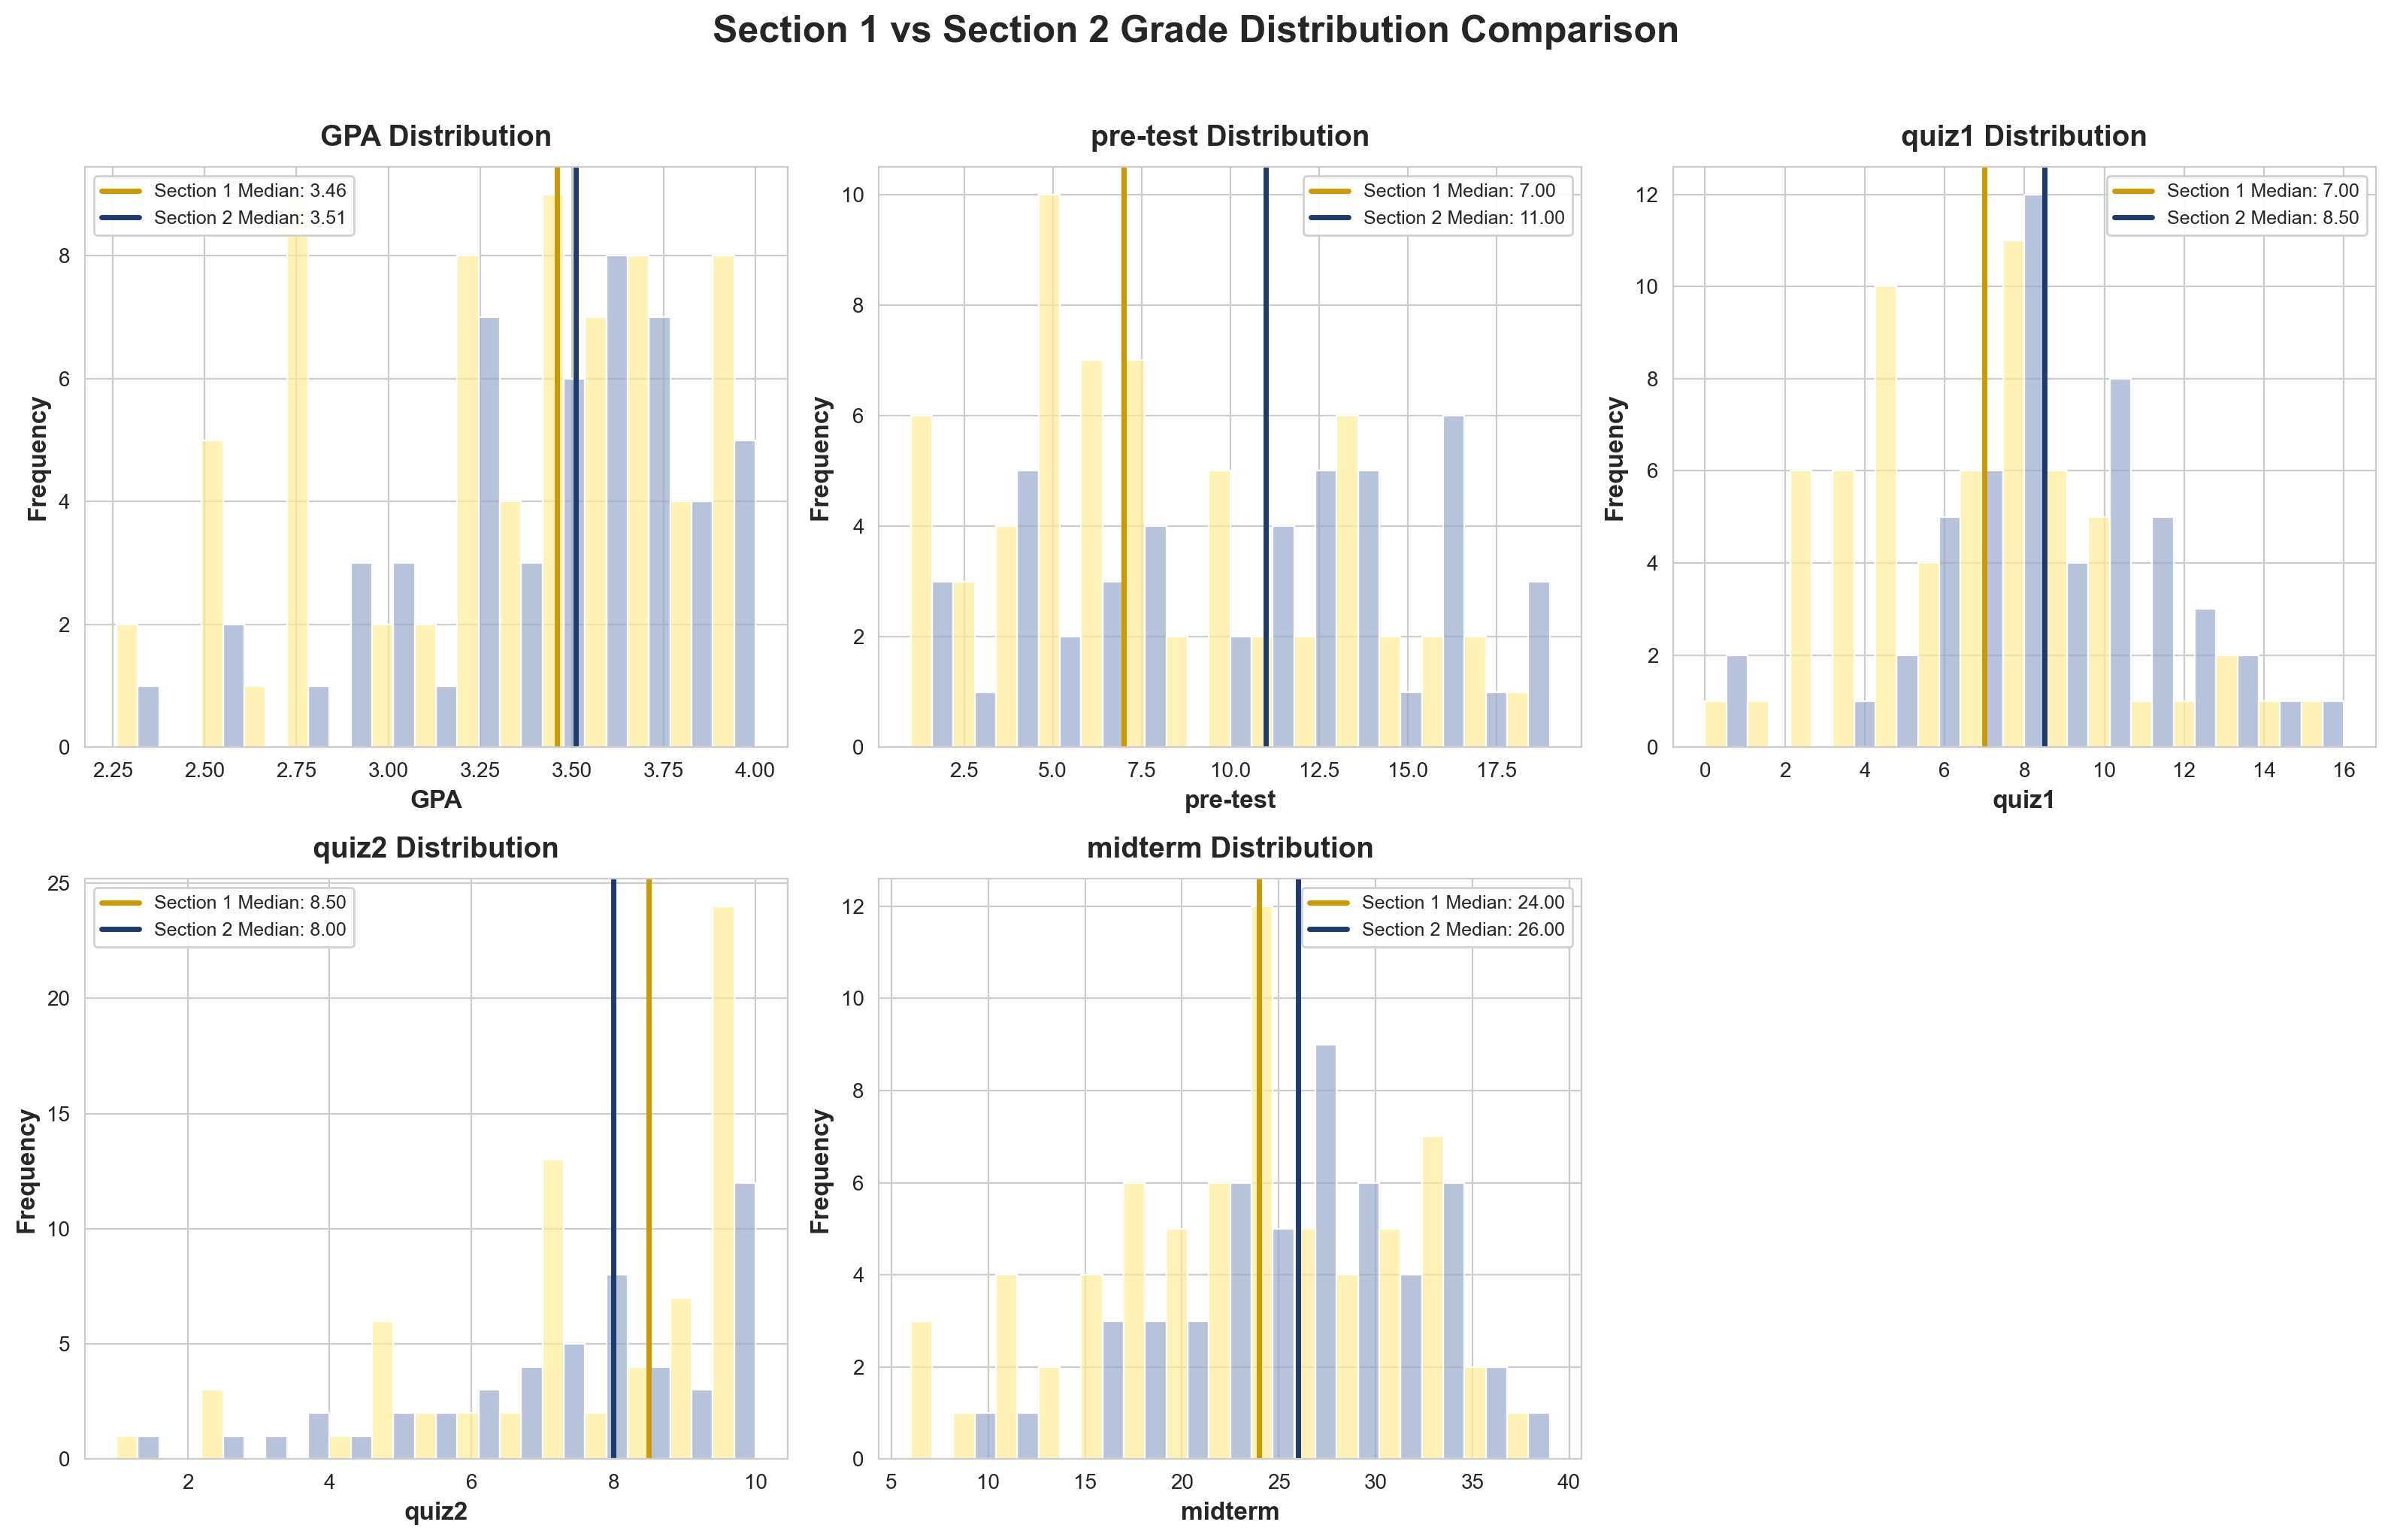

In [2]:
import math

# Dynamically compute grid size based on number of metrics
metrics_sections = ['GPA', 'pre-test', 'quiz1', 'quiz2', 'midterm' ]
n_metrics = len(metrics_sections)
n_cols = 3  # keep 3 columns
n_rows = math.ceil(n_metrics / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
fig.suptitle('Section 1 vs Section 2 Grade Distribution Comparison', 
             fontsize=18, fontweight='bold', y=1.02)
axes = np.array(axes).flatten()  # ← works for 1 row, 2 rows, or a single plot

# 2 colors: one per section
colors = {
    'Section 1': '#FFED99',   # Light yellow
    'Section 2': '#99AACC'    # Light navy
}

dark_colors = {
    'Section 1': '#CC9900',   # Dark yellow/gold
    'Section 2': '#1F3A6E'    # Dark navy
}

for idx, metric in enumerate(metrics_sections):
    ax = axes[idx]

    # Get data for each section
    section1_data = df[df['group'].isin(['Group A', 'Group B'])][metric].dropna()
    section2_data = df[df['group'] == 'Group C'][metric].dropna()

    # Calculate medians
    median_s1 = section1_data.median()
    median_s2 = section2_data.median()

    # Combine data
    plot_data = pd.DataFrame({
        metric: pd.concat([section1_data, section2_data]),
        'Section': ['Section 1'] * len(section1_data) +
                   ['Section 2'] * len(section2_data)
    })

    # Plot histograms
    sns.histplot(data=plot_data, x=metric, hue='Section', ax=ax,
                 palette=colors, alpha=0.7, kde=False, bins=15,
                 edgecolor='white', multiple='dodge')

    # Median lines
    ax.axvline(median_s1, color=dark_colors['Section 1'], linestyle='-',
               linewidth=2.5, label=f'Section 1 Median: {median_s1:.2f}')
    ax.axvline(median_s2, color=dark_colors['Section 2'], linestyle='-',
               linewidth=2.5, label=f'Section 2 Median: {median_s2:.2f}')

    # Styling
    ax.set_title(f'{metric} Distribution', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, loc='best', framealpha=0.9, fontsize=9)

# Hide any unused subplots
for idx in range(n_metrics, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('histograms_sections.png', dpi=300, bbox_inches='tight')
plt.show()

### Comparing Group A and Group B across GPA, Quizzes, HWs, Projects, and Exams

This part of the notebook generates:
- **Figure 1:** Box plots showing distribution comparisons
- **Figure 2:** Histograms with average lines marked

## Figure 1: Box Plots
Box plots show the distribution summary including median, quartiles, and outliers for each group.

/var/folders/34/pt4qzdh916q7nsrw967vxqrw0000gn/T/ipykernel_56853/934634113.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='group', y=metric, ax=ax, palette=colors,
/var/folders/34/pt4qzdh916q7nsrw967vxqrw0000gn/T/ipykernel_56853/934634113.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='group', y=metric, ax=ax, palette=colors,
/var/folders/34/pt4qzdh916q7nsrw967vxqrw0000gn/T/ipykernel_56853/934634113.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='group', y=metric, ax=ax, pa

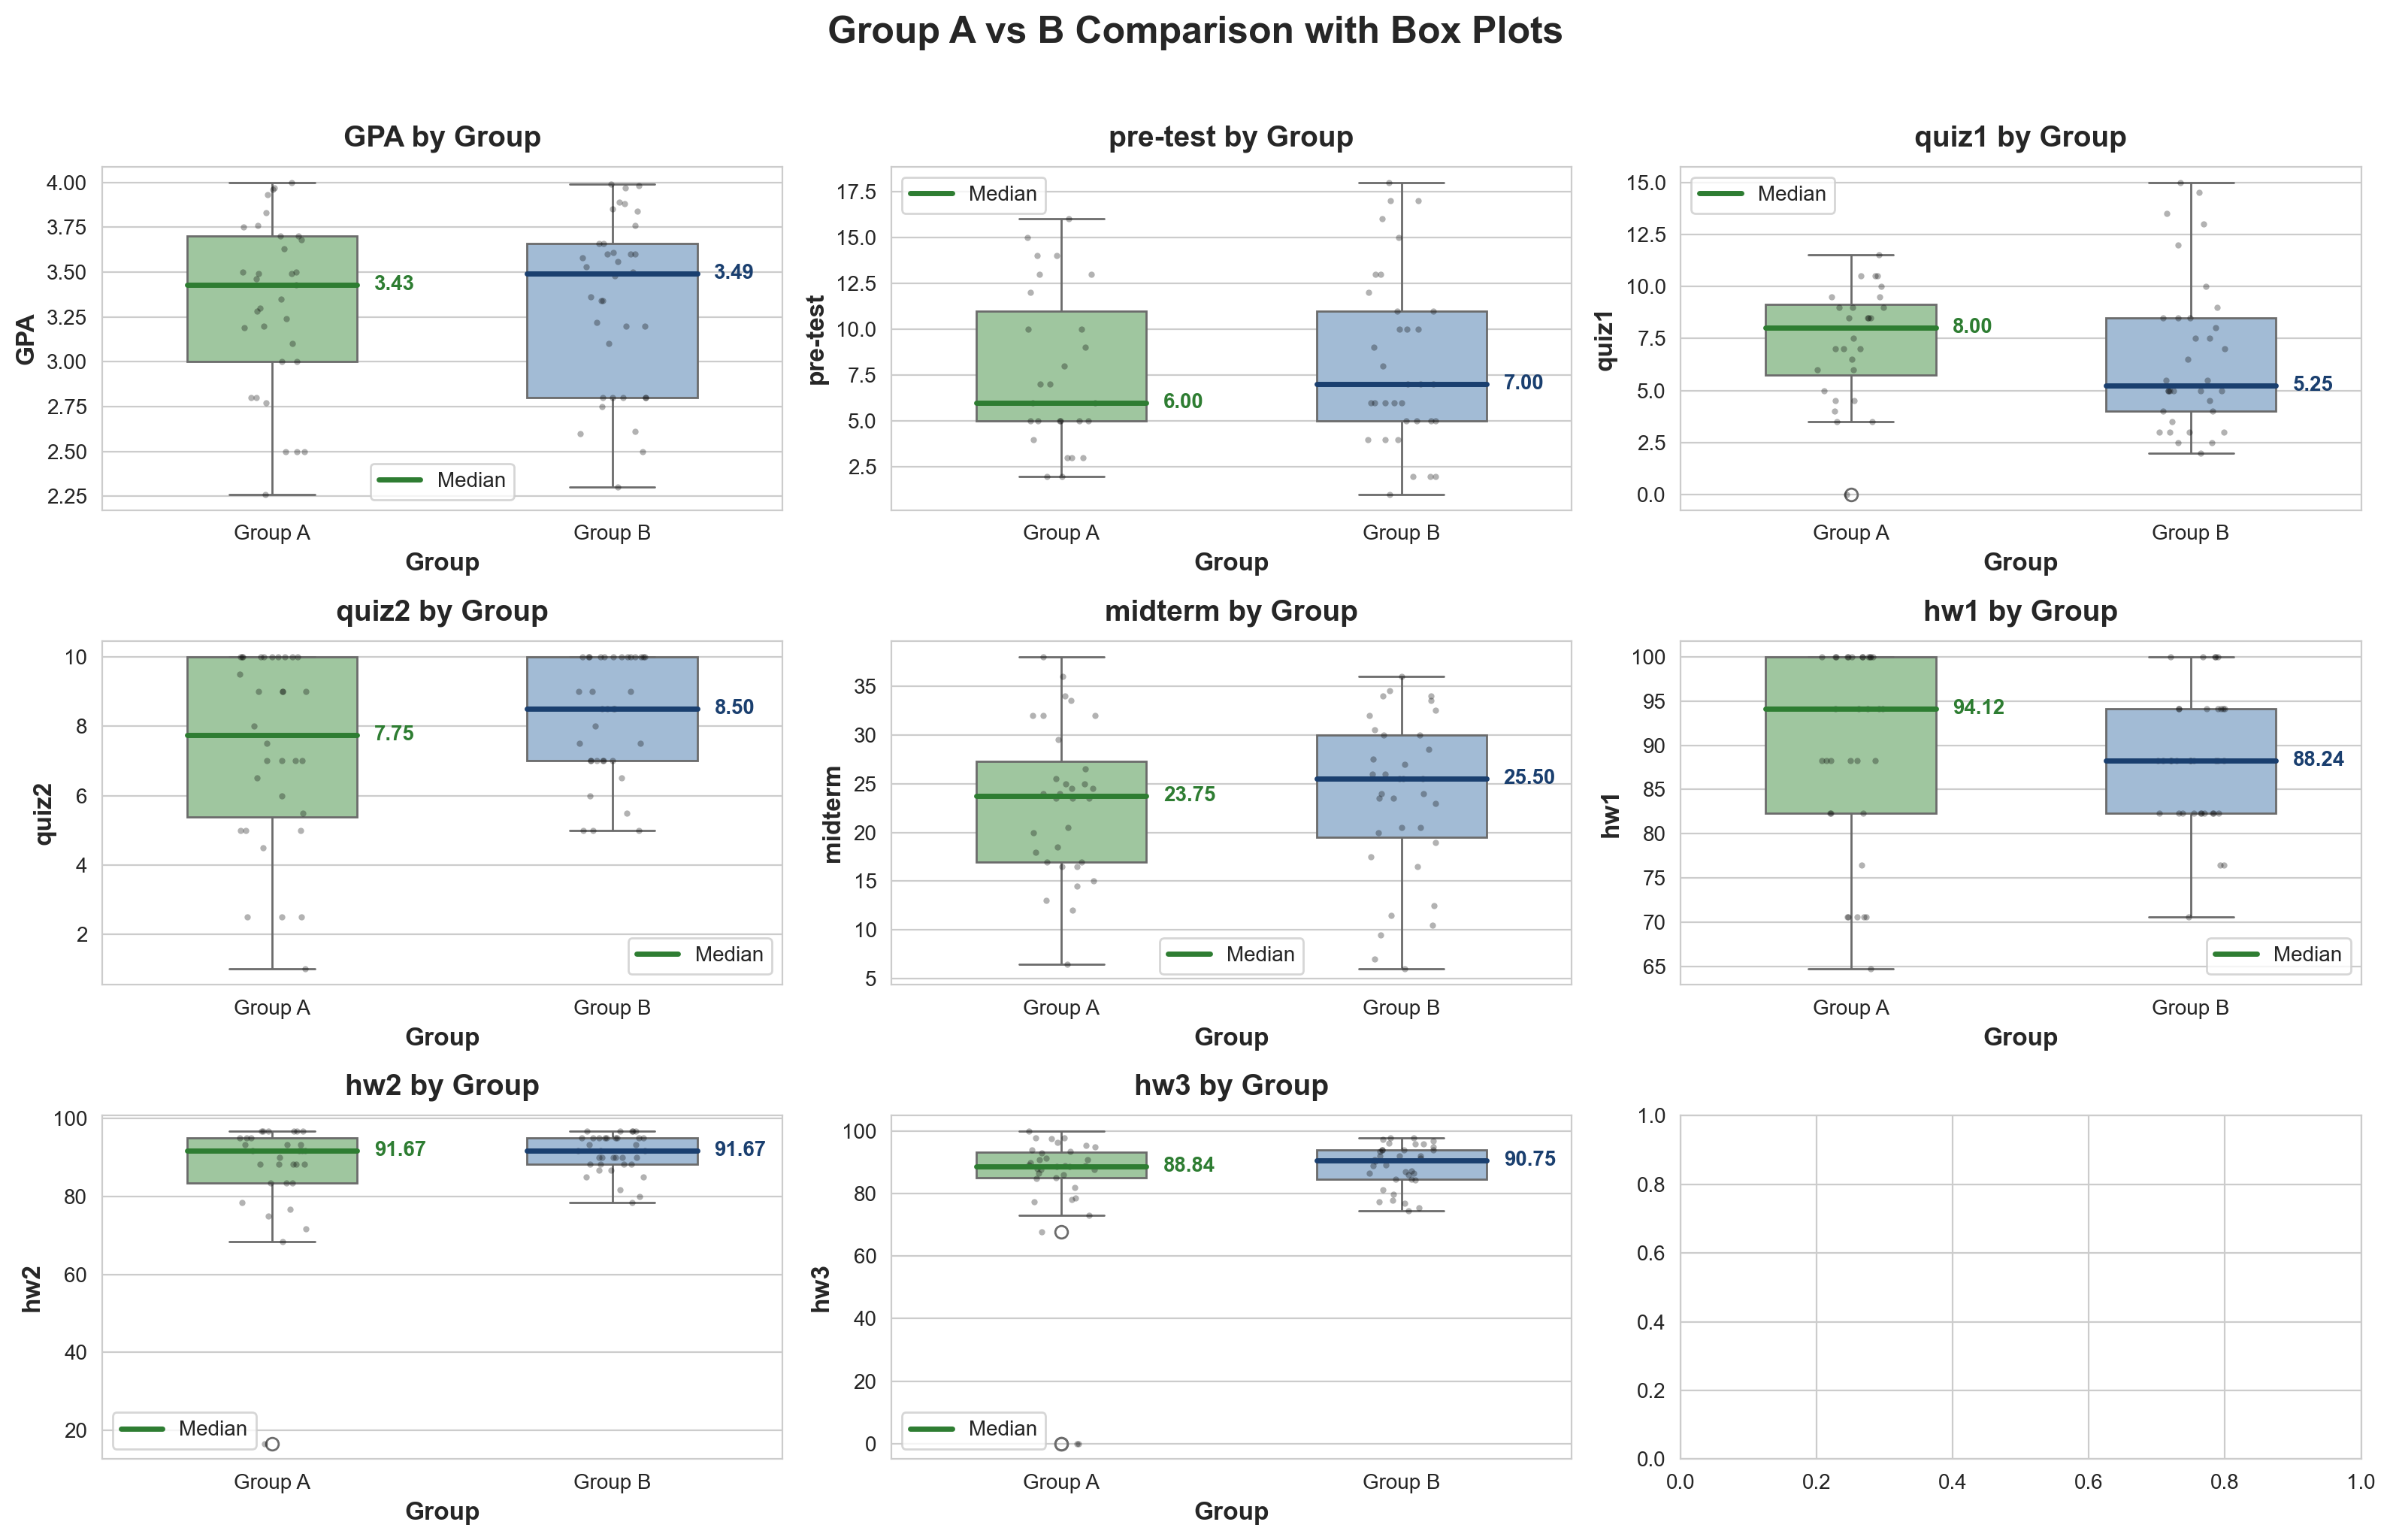

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
fig.suptitle('Group A vs B Comparison with Box Plots', fontsize=18, fontweight='bold', y=1.02)
axes = axes.flatten()  # converts 2D array to 1D for easy indexing
metrics = ['GPA', 'pre-test', 'quiz1', 'quiz2', 'midterm', 'hw1', 'hw2', 'hw3']

colors = {
        'Group A': '#99CC99',   # Light green
        'Group B': '#99BBDD'    # Light blue
}

dark_colors = {
'Group A': '#2E7D32',   # Dark green
'Group B': '#1A3F6F'    # Dark blue
}

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # Drop NA values for this specific metric only
    df_clean = df[['group', metric]].dropna()
    
    # Create box plot using seaborn with specific order
    sns.boxplot(data=df_clean, x='group', y=metric, ax=ax, palette=colors, 
                width=0.5, order=['Group A', 'Group B'])
    
    # Calculate median and mean values
    medians = df_clean.groupby('group')[metric].median()
    means = df_clean.groupby('group')[metric].mean()
    
    # Iterate through groups in correct order
    for pos, group in enumerate(['Group A', 'Group B']):
        median_val = medians[group]
        mean_val = means[group]
        
        # Get the x-axis limits for the lines
        x_left = pos - 0.25
        x_right = pos + 0.25
        
        # Add horizontal line for median (solid line) - use group's dark color
        ax.plot([x_left, x_right], [median_val, median_val], 
                color=dark_colors[group], linestyle='-', linewidth=2.5, zorder=10,
                label='Median' if pos == 0 else "")
        
        # Add text for median - use group's dark color
        ax.text(x_right + 0.05, median_val, f'{median_val:.2f}', 
                ha='left', va='center', fontweight='bold', 
                fontsize=10, color=dark_colors[group])
        
        # Add horizontal line for mean (dashed line) - use group's dark color
        #ax.plot([x_left, x_right], [mean_val, mean_val], 
                #color=dark_colors[group], linestyle='--', linewidth=2.5, zorder=10,
                #label='Mean' if pos == 0 else "")
        
        # Add text for mean - use group's dark color
        #ax.text(x_right + 0.05, mean_val, f'{mean_val:.2f}', 
                #ha='left', va='center', fontweight='bold', 
                #fontsize=10, color=dark_colors[group])
    
    # Add styling
    ax.set_title(f'{metric} by Group', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Group', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', framealpha=0.9, fontsize=10)
    
    # Optional: Add individual data points
    sns.stripplot(data=df_clean, x='group', y=metric, ax=ax, 
                  color='black', alpha=0.3, size=3, jitter=True, 
                  order=['Group A', 'Group B'])

plt.tight_layout()
plt.savefig('figure1_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 2: Histograms with Average Lines
Histograms show the full distribution of values with vertical lines marking the average (mean) for each group.

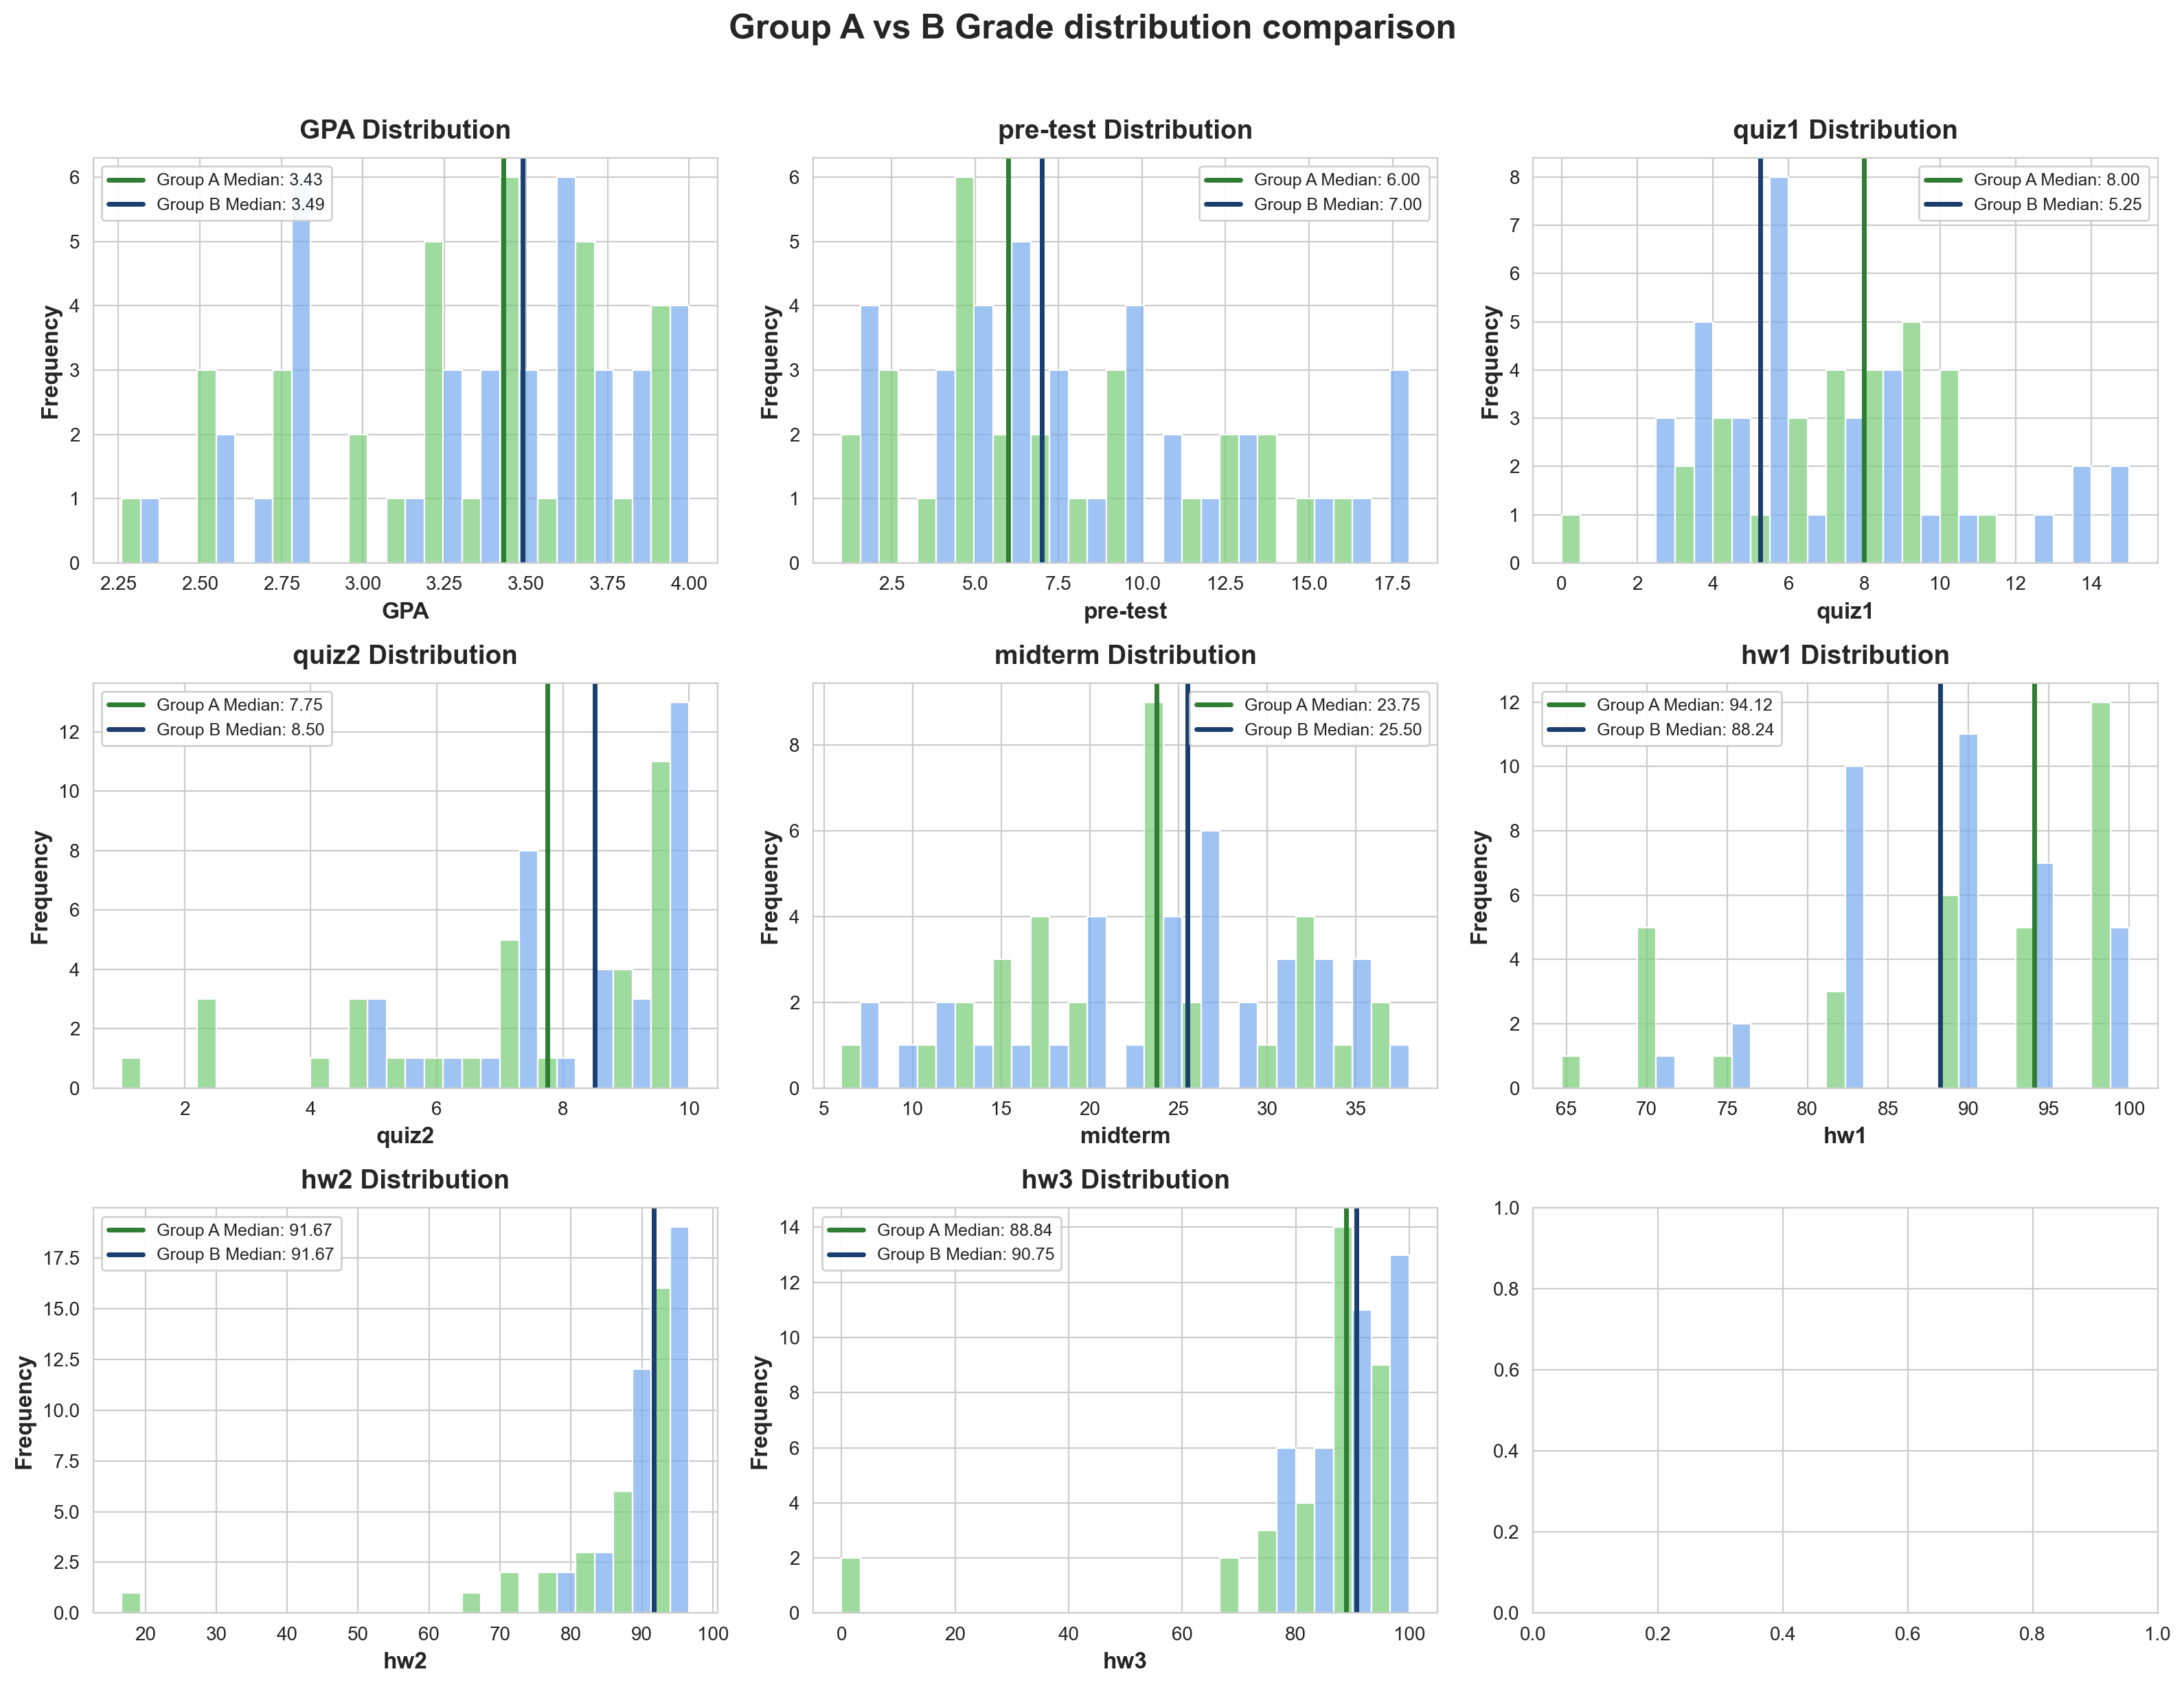

In [4]:
# Create Figure 2: Histograms with Average Lines
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Group A vs B Grade distribution comparison', fontsize=18, fontweight='bold', y=1.02)
axes = axes.flatten()  # converts 2D array to 1D for easy indexing

metrics = ['GPA', 'pre-test', 'quiz1', 'quiz2', 'midterm', 'hw1', 'hw2', 'hw3']

colors = {
    'Group A': '#77CC77',   # light green
    'Group B': '#77AAEE'    # light blue
}

dark_colors = {
'Group A': '#2E7D32',   # Dark green
'Group B': '#1A3F6F'    # Dark blue
}

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # Get data for each group
    group_a_data = df[df['group'] == 'Group A'][metric].dropna()
    group_b_data = df[df['group'] == 'Group B'][metric].dropna()
    
    # Calculate averages and medians
    avg_a = group_a_data.mean()
    avg_b = group_b_data.mean()
    median_a = group_a_data.median()
    median_b = group_b_data.median()
    
    # Combine data for side-by-side plotting
    plot_data = pd.DataFrame({
        metric: pd.concat([group_a_data, group_b_data]),
        'group': ['Group A']*len(group_a_data) + ['Group B']*len(group_b_data)
    })
    
    # Plot histograms side-by-side using seaborn
    sns.histplot(data=plot_data, x=metric, hue='group', ax=ax, 
                 palette=colors, alpha=0.7, kde=False, bins=15, 
                 edgecolor='white', multiple='dodge')
    
    # Add vertical lines for medians (solid lines) - darker colors
    ax.axvline(median_a, color=dark_colors['Group A'], linestyle='-', 
               linewidth=2.5, label=f'Group A Median: {median_a:.2f}')
    ax.axvline(median_b, color=dark_colors['Group B'], linestyle='-', 
               linewidth=2.5, label=f'Group B Median: {median_b:.2f}')
    
    # Add vertical lines for averages (dashed lines) - darker colors
    #ax.axvline(avg_a, color=dark_colors['Group A'], linestyle='--', 
               #linewidth=2.5, label=f'Group A Mean: {avg_a:.2f}')
    #ax.axvline(avg_b, color=dark_colors['Group B'], linestyle='--', 
               #linewidth=2.5, label=f'Group B Mean: {avg_b:.2f}')
    
    # Styling
    ax.set_title(f'{metric} Distribution', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, loc='best', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig('histograms_groups.png', dpi=300, bbox_inches='tight')
plt.show()


## Combined Summary Table
View all statistics in a single table for easy comparison.

In [ ]:
# Create a comprehensive summary table
summary_list = []

for metric in metrics:
    for group in ['Group A', 'Group B', 'Group C']:
        data = df[df['group'] == group][metric].dropna()
        summary_list.append({
            'Metric': metric,
            'Group': group,
            'Mean': round(data.mean(), 3),
            'Median': round(data.median(), 3),
            'Std Dev': round(data.std(), 3),
            'Min': round(data.min(), 3),
            'Max': round(data.max(), 3),
            'Count': len(data)
        })

summary_table = pd.DataFrame(summary_list)
display(summary_table)

### One-way ANOVA table between the 3 groups

In [12]:
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Load the data
df = pd.read_csv('students_groups.csv', encoding='latin-1')
df.columns = df.columns.str.replace('-', '_').str.replace(' ', '_')

metrics = ['GPA', 'pre_test', 'quiz1', 'quiz2', 'midterm']
for metric in metrics:
    model = ols(f'{metric} ~ C(group)', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=1)
    anova_table.index = ['Group (Between)', 'Residual (Within)']
    anova_table.columns = ['Sum of Squares', 'df', 'Mean Square', 'F', 'Sig.']

    # Add Total row
    total = pd.DataFrame({
        'Sum of Squares': [anova_table['Sum of Squares'].sum()],
        'df':             [anova_table['df'].sum()],
        'Mean Square':    [float('nan')],
        'F':              [float('nan')],
        'Sig.':           [float('nan')]
    }, index=['Total'])

    anova_table = pd.concat([anova_table, total])
    anova_table['df'] = anova_table['df'].astype(int)

    print(f"\n{'='*60}")
    print(f"ANOVA Table — {metric}")
    print(f"{'='*60}")
    print(anova_table.round(3).to_string())


PatsyError: error tokenizing input (maybe an unclosed string?)
    `GPA` ~ C(group)
    ^

### One-way ANOVA and Tukey's HSD as Post-hoc test between the 3 groups

In [10]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Load the data
df = pd.read_csv('students_groups.csv', encoding='latin-1')

metrics = ['GPA', 'pre-test', 'quiz1', 'quiz2', 'midterm']

for metric in metrics:
    # Collect each group's data as a separate array
    groups_data = [
        df[df['group'] == group][metric].dropna()
        for group in ['Group A', 'Group B', 'Group C']
    ]

    # Step 1: One-way ANOVA — pass each group array as a separate argument
    f_stat, p_val = stats.f_oneway(*groups_data)
    print(f"{metric}: F={f_stat:.3f}, p={p_val:.3f}")

    # Step 2: Tukey's HSD only if ANOVA is significant
    if p_val < 0.05:
        mask = df[metric].notna()
        tukey = pairwise_tukeyhsd(
            df.loc[mask, metric],
            df.loc[mask, 'group']
        )
        print(tukey.summary())

GPA: F=0.768, p=0.466
pre-test: F=3.107, p=0.049
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
Group A Group B   0.5686 0.8917  -2.394 3.5312  False
Group A Group C   2.6444 0.0681 -0.1533 5.4422  False
Group B Group C   2.0758 0.1467 -0.5357 4.6874  False
-----------------------------------------------------
quiz1: F=4.352, p=0.015
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj  lower  upper  reject
----------------------------------------------------
Group A Group B  -0.7038 0.663 -2.6351 1.2276  False
Group A Group C   1.3036 0.193 -0.4704 3.0776  False
Group B Group C   2.0074 0.014  0.3382 3.6765   True
----------------------------------------------------
quiz2: F=2.002, p=0.140
midterm: F=1.695, p=0.188


In [ ]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Load the data
df = pd.read_csv('students_groups.csv', encoding='latin-1')

metrics = ['GPA', 'pre-test', 'quiz1', 'quiz2', 'midterm', 'hw1', 'hw2', 'hw3']

for metric in metrics:
    # Collect each group's data as a separate array
    groups_data = [
        df[df['group'] == group][metric].dropna()
        for group in ['Group A', 'Group B', 'Group C']
    ]

    # Step 1: One-way ANOVA — pass each group array as a separate argument
    f_stat, p_val = stats.f_oneway(*groups_data)
    print(f"{metric}: F={f_stat:.3f}, p={p_val:.3f}")

    # Step 2: Tukey's HSD only if ANOVA is significant
    if p_val < 0.05:
        mask = df[metric].notna()
        tukey = pairwise_tukeyhsd(
            df.loc[mask, metric],
            df.loc[mask, 'group']
        )
        print(tukey.summary())